# Coloración de Grafos
## MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

**Resumen**
El presente proyecto tiene como finalidad desarrollar un algoritmo bioinspirado genético para la solución del problema de coloración de grafos. El objetivo final será poder colorear los nodos con la cantidad mínima de colores, de forma que los nodos adyacentes no posean el mismo color.

### 1. Importación de Librerías y Configuración Inicial

In [95]:
import pulp, random
import matplotlib.pyplot as plt
import time

In [96]:
V = list(range(1, 20))

# Aristas (basado en la imagen del grafo)
E = [
(1,2),(1,4),(1,16),
(2,1),(2,4),(2,5),(2,6),(2,7),(2,3),
(3,2),(3,7),(3,11),(3,19),
(4,1),(4,2),(4,5),(4,9),(4,8),
(5,2),(5,4),(5,6),(5,9),(5,10),
(6,2),(6,5),(6,7),(6,11),(6,14),
(7,2),(7,3),(7,6),(7,11),
(8,4),(8,9),(8,12),(8,16),
(9,4),(9,5),(9,8),(9,10),(9,12),(9,13),(9,15),
(10,5),(10,9),(10,13),(10,14),
(11,3),(11,7),(11,6),(11,14),(11,19),
(12,8),(12,9),(12,16),(12,15),
(13,9),(13,10),(13,14),(13,15),(13,17),(13,18),
(14,6),(14,11),(14,10),(14,13),(14,18),(14,19),
(15,12),(15,9),(15,13),(15,17),(15,16),
(16,1),(16,8),(16,12),(16,15),(16,17),
(17,16),(17,15),(17,13),(17,18),(17,19),
(18,17),(18,13),(18,14),(18,19),
(19,17),(19,18),(19,14),(19,11),(19,3)
]

NUM_NODOS = len(V)
MAX_COLORES = NUM_NODOS  # Peor caso: cada nodo un color diferente


### 2. Solución Exacta

In [97]:
def metodo_matematico():
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    
    print("MÉTODO MATEMÁTICO (PuLP)")
    
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("Funcionaaaaa!!!!!!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO COLORES ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio



## 3. Algoritmo Genético

In [98]:
"""
PARÁMETROS DEL ALGORITMO GENÉTICO:
- Tipo de cromosoma: Lista de enteros (cada gen = color del nodo)
- Longitud: 19 genes (uno por nodo)
- Tamaño población: 50 individuos
- Inicialización: Aleatoria, empezando con muchos colores
- Criterio infactibilidad: Contar conflictos (aristas mismo color)
- Criterio de paro: 200 generaciones o fitness = 0
- Función fitness: Penaliza conflictos + número de colores usados
- Selección: Torneo de tamaño 3
- Probabilidad cruce: 0.8
- Puntos de cruce: 1 punto
- Probabilidad mutación: 0.15
- Reemplazo: Generacional con elitismo
"""

TAM_POBLACION = 80
GENERACIONES = 150 #porq si
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3

def crear_individuo(num_colores):
    """Crea un cromosoma aleatorio con num_colores colores disponibles"""
    return [random.randint(1, num_colores) for _ in range(NUM_NODOS)]

def contar_conflictos(cromosoma):
    """Cuenta cuántas aristas tienen nodos del mismo color"""
    conflictos = 0
    for (i, j) in E:
        if cromosoma[i-1] == cromosoma[j-1]:
            conflictos += 1
    return conflictos

def contar_colores(cromosoma):
    """Cuenta cuántos colores diferentes se usan"""
    return len(set(cromosoma))

def calcular_fitness(cromosoma):
    """
    Fitness combinado:
    - Penalización alta por conflictos (x1000)
    - Penalización baja por número de colores
    Menor fitness = mejor solución
    """
    conflictos = contar_conflictos(cromosoma)
    colores = contar_colores(cromosoma)
    return conflictos * 1000 + colores

def seleccion_torneo(poblacion, fitnesses):
    """Selección por torneo"""
    participantes = random.sample(range(len(poblacion)), TAM_TORNEO)
    mejor = min(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor].copy()

def cruce(padre1, padre2):
    """Cruce de un punto"""
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, NUM_NODOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion(cromosoma, num_colores):
    """Mutación: cambiar color de un gen aleatorio"""
    for i in range(len(cromosoma)):
        if random.random() < PROB_MUTACION:
            cromosoma[i] = random.randint(1, num_colores)
    return cromosoma

def reducir_colores(cromosoma):
    """
    Renumera los colores para eliminar huecos
    Ej: [1,3,5,3,1] -> [1,2,3,2,1]
    """
    colores_usados = sorted(set(cromosoma))
    mapeo = {c: i+1 for i, c in enumerate(colores_usados)}
    return [mapeo[c] for c in cromosoma]


In [99]:

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético para encontrar el número cromático mínimo
    Estrategia: empezar con muchos colores e ir reduciendo progresivamente
    """
    
    print("ALGORITMO GENÉTICO")
    
    
    inicio = time.time()
    
    # Guardar historial
    historial_mejor = []
    historial_colores = []
    
    mejor_solucion_global = None
    mejor_colores_global = NUM_NODOS
    
    # ESTRATEGIA: Probar con cada número de colores, de mayor a menor
    # Empezamos con 10 colores (suficiente para este grafo)
    
    for num_colores_actual in range(10, 0, -1):
        print(f"\nProbando con {num_colores_actual} colores...")
        
        # Más generaciones para números pequeños de colores (más difícil)
        gen_actuales = GENERACIONES if num_colores_actual > 5 else GENERACIONES * 3
        
        # Inicialización de población para este número de colores
        poblacion = [crear_individuo(num_colores_actual) for _ in range(TAM_POBLACION)]
        
        mejor_individuo = None
        mejor_conflictos = float('inf')
        
        # Correr generaciones para este número de colores
        for gen in range(gen_actuales):
            fitnesses = [contar_conflictos(ind) for ind in poblacion]
            
            # Actualizar mejor
            idx_mejor = fitnesses.index(min(fitnesses))
            if fitnesses[idx_mejor] < mejor_conflictos:
                mejor_conflictos = fitnesses[idx_mejor]
                mejor_individuo = poblacion[idx_mejor].copy()
            
            # Guardar historial
            historial_mejor.append(mejor_conflictos)
            historial_colores.append(num_colores_actual)
            
            # Si encontramos solución sin conflictos, éxito!
            if mejor_conflictos == 0:
                break
            
            # Crear nueva población
            nueva_poblacion = []
            
            # Elitismo
            nueva_poblacion.append(mejor_individuo.copy())
            
            while len(nueva_poblacion) < TAM_POBLACION:
                padre1 = seleccion_torneo(poblacion, fitnesses)
                padre2 = seleccion_torneo(poblacion, fitnesses)
                
                hijo1, hijo2 = cruce(padre1, padre2)
                
                hijo1 = mutacion(hijo1, num_colores_actual)
                hijo2 = mutacion(hijo2, num_colores_actual)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < TAM_POBLACION:
                    nueva_poblacion.append(hijo2)
            
            poblacion = nueva_poblacion
        
        # Verificar si encontramos solución válida con este número de colores
        if mejor_conflictos == 0:
            print(f" FUNCIONAAAAA, Conflictos=0")
            mejor_solucion_global = mejor_individuo.copy()
            mejor_colores_global = num_colores_actual
            # Seguir intentando con menos colores
        else:
            print(f"  No factible (mejor conflictos={mejor_conflictos})")
            # No se puede con menos colores, terminar
            break
    
    fin = time.time()
    tiempo = fin - inicio
    
    # Usar la mejor solución encontrada
    if mejor_solucion_global is not None:
        mejor_individuo = reducir_colores(mejor_solucion_global)
        solucion = {i+1: mejor_individuo[i] for i in range(NUM_NODOS)}
        num_colores = contar_colores(mejor_individuo)
        conflictos = 0
    else:
        solucion = {i+1: i+1 for i in range(NUM_NODOS)}
        num_colores = NUM_NODOS
        conflictos = 0
    
    print(f"\n*** NÚMERO COLORES ENCONTRADO: {num_colores} ***")
    print(f"Conflictos: {conflictos}")
    print(f"Tiempo: {tiempo:.4f} segundos")
    print(f"Asignación: {solucion}")
    
    return solucion, num_colores, tiempo, historial_mejor, historial_colores, conflictos



In [100]:
def ejemplitooo():
    """Muestra un ejemplo detallado del algoritmo genético"""
    
    print("Ejemplo ejecucion")
    
    
    print("\n1. CREAR POBLACIÓN INICIAL (3 individuos)")
    print("   (Empezamos con hasta 6 colores disponibles)")
    mini_pop = [crear_individuo(6) for _ in range(3)]
    for i, ind in enumerate(mini_pop):
        conf = contar_conflictos(ind)
        cols = contar_colores(ind)
        print(f"   Individuo {i+1}: {ind[:6]}... Conflictos={conf}, Colores={cols}")
    
    print("\n2. CALCULAR FITNESS")
    print("   Fitness = conflictos*1000 + colores")
    for i, ind in enumerate(mini_pop):
        fit = calcular_fitness(ind)
        print(f"   Individuo {i+1}: Fitness = {fit}")
    
    print("\n3. SELECCIÓN POR TORNEO (tamaño 3)")
    fitnesses = [calcular_fitness(ind) for ind in mini_pop]
    padre1 = seleccion_torneo(mini_pop, fitnesses)
    padre2 = seleccion_torneo(mini_pop, fitnesses)
    print(f"   Padre 1 seleccionado: {padre1[:6]}...")
    print(f"   Padre 2 seleccionado: {padre2[:6]}...")
    
    print("\n4. CRUCE DE UN PUNTO")
    punto = 10
    hijo = padre1[:punto] + padre2[punto:]
    print(f"   Punto de cruce: posición {punto}")
    print(f"   Hijo: {hijo[:6]}...")
    
    print("\n5. MUTACIÓN (prob=0.15 por gen)")
    hijo_original = hijo.copy()
    hijo = mutacion(hijo, 6)
    cambios = sum(1 for a, b in zip(hijo_original, hijo) if a != b)
    print(f"   Genes mutados: {cambios}")
    
    print("\n6. REDUCIR COLORES")
    print(f"   Antes: {hijo[:6]}... usa colores {sorted(set(hijo))}")
    hijo = reducir_colores(hijo)
    print(f"   Después: {hijo[:6]}... usa colores {sorted(set(hijo))}")
    
    print("\n7. EVALUAR NUEVO INDIVIDUO")
    print(f"   Conflictos: {contar_conflictos(hijo)}")
    print(f"   Colores usados: {contar_colores(hijo)}")
    print(f"   Fitness: {calcular_fitness(hijo)}")



### 4. Visualización

In [101]:
def graficar_resultados(hist_conflictos, hist_colores, t_mat, t_ag, col_mat, col_ag):
    """Genera gráficas de comparación"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gráfica 1: Evolución de conflictos
    axes[0].plot(hist_conflictos, 'b-', linewidth=2)
    axes[0].set_xlabel('Generación')
    axes[0].set_ylabel('Conflictos')
    axes[0].set_title('Evolución de Conflictos (AG)')
    axes[0].grid(True)
    
    # Gráfica 2: Evolución de colores
    axes[1].plot(hist_colores, 'g-', linewidth=2)
    axes[1].set_xlabel('Generación')
    axes[1].set_ylabel('Número de colores')
    axes[1].set_title('Evolución de Colores Usados (AG)')
    axes[1].grid(True)
    
    # Gráfica 3: Comparación final
    metodos = ['Matemático\n(PuLP)', 'Algoritmo\nGenético']
    colores_final = [col_mat, col_ag]
    tiempos = [t_mat, t_ag]
    
    x = range(len(metodos))
    width = 0.35
    
    bars1 = axes[2].bar([i - width/2 for i in x], colores_final, width, label='Colores', color='steelblue')
    axes[2].set_ylabel('Número de colores')
    axes[2].set_title('Comparación de Métodos')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metodos)
    
    ax2 = axes[2].twinx()
    bars2 = ax2.bar([i + width/2 for i in x], tiempos, width, label='Tiempo', color='coral')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Etiquetas
    for bar, val in zip(bars1, colores_final):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(val), ha='center', fontsize=10)
    for bar, val in zip(bars2, tiempos):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()



In [102]:

def imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag):
    """Imprime tabla de comparación"""
    print("TABLA DE COMPARACIÓN DE RESULTADOS")
    print(f"{'Criterio':<30} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    print(f"{'Número cromático (χ)':<30} {col_mat:<15} {col_ag:<15}")
    print(f"{'Conflictos':<30} {0:<15} {conf_ag:<15}")
    print(f"{'Tiempo (segundos)':<30} {t_mat:<15.4f} {t_ag:<15.4f}")
    print(f"{'Solución óptima':<30} {'Sí':<15} {'Sí' if conf_ag == 0 else 'No':<15}")

    
    print("ASIGNACIÓN DE COLORES POR NODO")
    print(f"{'Nodo':<8} {'Matemático':<15} {'Genético':<15}")
    for nodo in V:
        print(f"{nodo:<8} {sol_mat[nodo]:<15} {sol_ag[nodo]:<15}")


### * EJECUTAR *

PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (χ)
Grafo: 19 nodos, 92 aristas
MÉTODO MATEMÁTICO (PuLP)
Probando con 1 colores... No factible
Probando con 2 colores... No factible
Probando con 3 colores... No factible
Probando con 4 colores... Funcionaaaaa!!!!!!

*** NÚMERO COLORES ENCONTRADO: 4 ***
Tiempo total: 0.1015 segundos
Asignación: {1: 2, 2: 4, 3: 3, 4: 1, 5: 2, 6: 1, 7: 2, 8: 2, 9: 3, 10: 1, 11: 4, 12: 4, 13: 4, 14: 3, 15: 2, 16: 1, 17: 3, 18: 2, 19: 1}
ALGORITMO GENÉTICO

Probando con 10 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 9 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 8 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 7 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 6 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 5 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 4 colores...
 FUNCIONAAAAA, Conflictos=0

Probando con 3 colores...
  No factible (mejor conflictos=6)

*** NÚMERO COLORES ENCONTRADO:

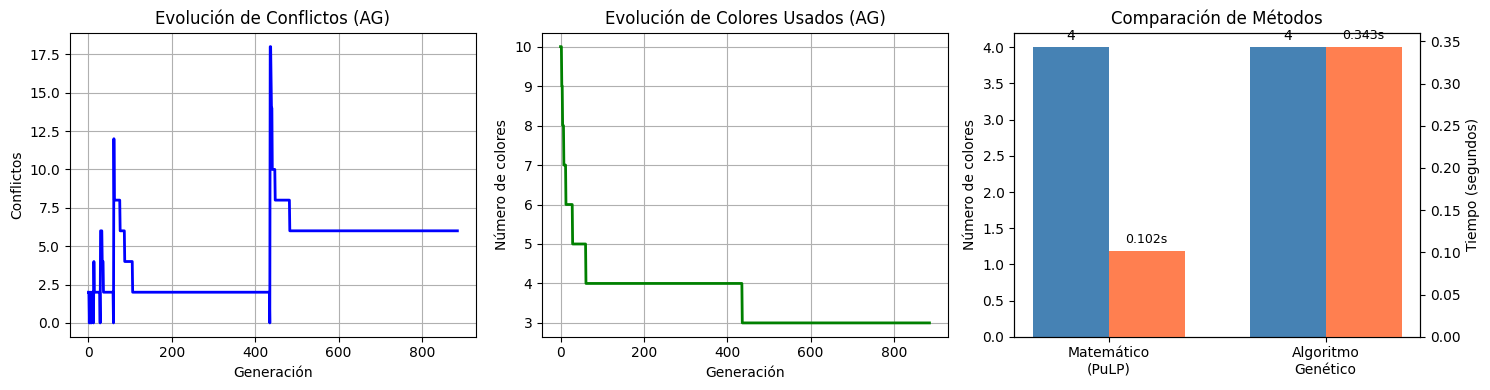

In [103]:
if __name__ == "__main__":
    print("PROBLEMA DE COLORACIÓN DE GRAFOS")
    print("Objetivo: Encontrar el MÍNIMO número de colores (χ)")
    print(f"Grafo: {NUM_NODOS} nodos, {len(E)} aristas")
    
    # Ejemplo paso a paso
    '''
    es para no hacerlo a mano pq si me daba mucha hueva jaja
    '''
    #ejemplitooo()
    
    # Método matemático
    sol_mat, col_mat, t_mat = metodo_matematico()
    
    # Algoritmo genético
    sol_ag, col_ag, t_ag, hist_conf, hist_col, conf_ag = algoritmo_genetico()
    
    # Tabla de comparación
    imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag)
    
    # Gráficas
    graficar_resultados(hist_conf, hist_col, t_mat, t_ag, col_mat, col_ag)